In [7]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [9]:
df = df[df['job_title_short'] == 'Data Analyst']

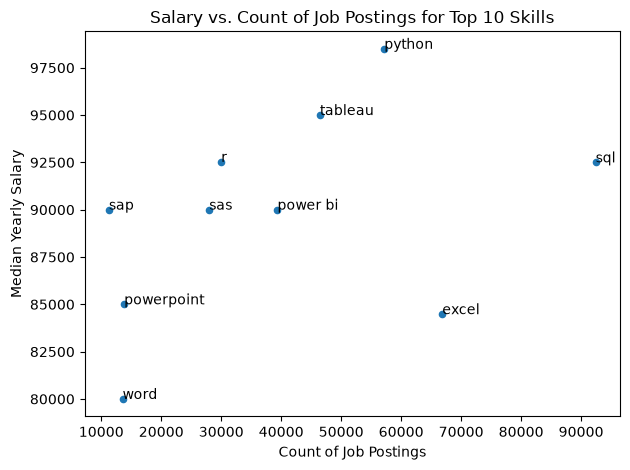

In [28]:
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills','count'),
    median_salary = ('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()

for i,text in enumerate(skill_stats.index):
     plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], text)
plt.show()

In [32]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



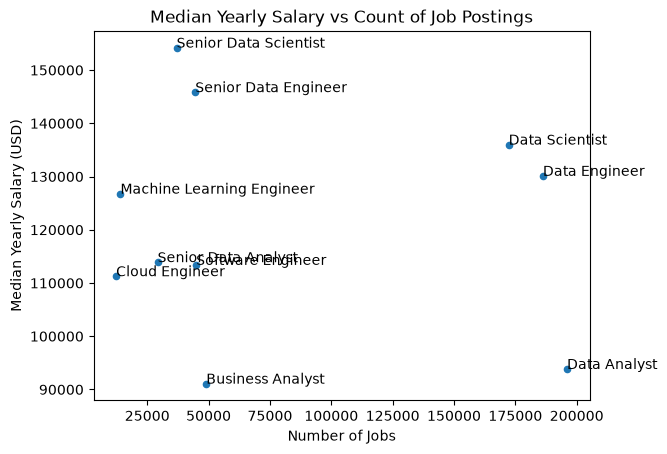

In [45]:
# Create a scatter plot to compare the median yearly salary and the number of jobs based on the job_title_short column.
# To create the scatter plot first create a new DataFrame using the groupby() method to aggregate and find the median salary and job count for each job title.
# Annotate each point with the job title name.

job_stats = df.groupby('job_title_short').agg(
    title_count = ('job_title_short', 'count'),
    salary_avg = ('salary_year_avg', 'mean')
).copy()

job_stats.plot(kind='scatter', x='title_count', y='salary_avg')
plt.xlabel('Number of Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Median Yearly Salary vs Count of Job Postings')

for i,title in enumerate(job_stats.index):
    plt.text(job_stats['title_count'].iloc[i], job_stats['salary_avg'].iloc[i], title)

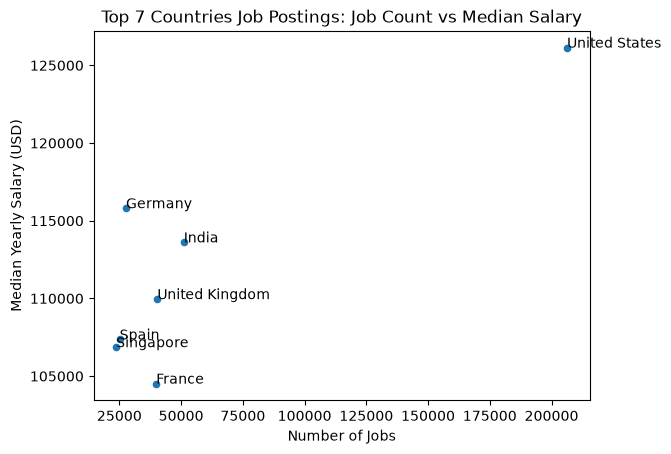

In [61]:
# Create a scatter plot to visualize the relationship between the number of job postings and median yearly salary for the top 7 countries based on highest number of job postings. 
# Annotate each point with the country's name.
country_stats = df.groupby('job_country').agg(
    job_count = ('job_country', 'count'),
    average_salary = ('salary_year_avg', 'mean')
).dropna().copy()

country_stats = country_stats.sort_values(by='job_count', ascending=False).head(7)

country_stats.plot(kind='scatter', x='job_count', y='average_salary')
plt.xlabel('Number of Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Top 7 Countries Job Postings: Job Count vs Median Salary')

for i, country in enumerate(country_stats.index):
    plt.text(country_stats['job_count'].iloc[i], country_stats['average_salary'].iloc[i], country)

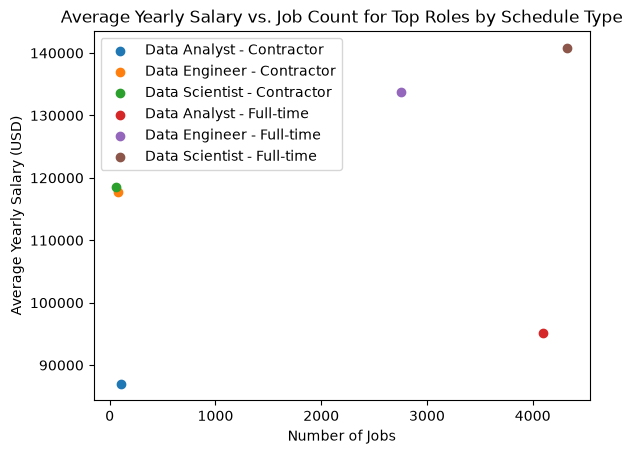

In [66]:
# Create a scatter plot to visualize the relationship between the average yearly salary and the job count filtering a DataFrame for:
# Data Analyst, Data Scientist, and Data Engineer positions in job_title_short
# United States for the job_country
# 'Full-time' and 'Contractor' for the job_schedule_type
# Remove roles that do not have any yearly salary data.
# Combine the job_title_short and job_schedule_type into one column (called job_title_type) in the newly created DataFrame to use as the labels for the plot.
# For the plot use a for loop to cycle through the unique values in job_title_type and plot using the plt.scatter() function, specifying the label of job_title_type.
# Ensure the legend is appearing.
# Label the plot's axis and title appropriately.

target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

us_jobs_df = df[
   (df['job_country'] == 'United States') &
   (df['job_schedule_type'].isin(['Full-time', 'Contractor'])) &
   (df['job_title_short'].isin(target_job_titles))
].dropna(subset=['salary_year_avg']).copy()

stats = us_jobs_df.groupby(['job_schedule_type', 'job_title_short']).agg(
   mean_salary_year_avg=('salary_year_avg', 'mean'),
   job_count=('job_title_short', 'count')
).dropna()

stats.reset_index(inplace=True)


stats['job_title_type'] = stats['job_title_short'] + ' - ' + stats['job_schedule_type']


for job_title_type in stats['job_title_type'].unique():
   subset = stats[stats['job_title_type'] == job_title_type]
   plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)

plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary (USD)')
plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')
plt.legend()
plt.show()